# Linear Programming: Overview & tools in Python 

Example problem:

\begin{aligned}
\min_{x_1,x_2}\quad & 3x_1 + 2x_2 \\
\text{s.t.}\quad & x_1 + x_2 \ge 4, \\
\text{s.t.}\quad & x_1 + 3x_2 \ge 6, \\
& x_1, x_2 \ge 0.
\end{aligned}

### LP Interfaces in Pyton: `Pyomo` and `scipy.optimize.linprog`

- `Pyomo`: a modeling language for optimization
- `SciPy linprog`: a direct solver interface for LPs

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

## 1. Pyomo interface

Pyomo lets you build optimization models using symbolic variables, objectives, and constraints.

Example problem:

\begin{aligned}
\min_{x_1,x_2}\quad & 3x_1 + 2x_2 \\
\text{s.t.}\quad & x_1 + x_2 \ge 4, \\
\text{s.t.}\quad & x_1 + 3x_2 \ge 6, \\
& x_1, x_2 \ge 0.
\end{aligned}

In [5]:
import pyomo.environ as pyo
from pyomo.opt import SolverStatus, TerminationCondition

In [6]:
model = pyo.ConcreteModel()
model.x = pyo.Var(domain=pyo.NonNegativeReals)
model.y = pyo.Var(domain=pyo.NonNegativeReals)

model.obj = pyo.Objective(expr=3 * model.x + 2 * model.y, sense=pyo.maximize)
model.c1 = pyo.Constraint(expr=model.x + model.y <= 4)
model.c2 = pyo.Constraint(expr=model.x + 3 * model.y <= 6)

solver = pyo.SolverFactory('glpk')
# solver = pyo.SolverFactory("gurobi")
result = solver.solve(model, tee=False)

In [7]:
if (result.solver.status == SolverStatus.ok and
    result.solver.termination_condition == TerminationCondition.optimal):
    print("Optimal solution found")
    print(f"x = {pyo.value(model.x):.4f}")
    print(f"y = {pyo.value(model.y):.4f}")
    print(f"objective = {pyo.value(model.obj):.4f}")
else:
    print(result.solver.status, result.solver.termination_condition)

Optimal solution found
x = 4.0000
y = 0.0000
objective = 12.0000


Pyomo notes:

- Pyomo is useful when your model has rich structure (sets, indexed variables, mixed-integer constraints).
- You define a symbolic model first, then pass it to a solver.
- You can specify a solver of your choice (gurobi, cplex, HiGHS, cyipopt, ...)

## 2. SciPy [linprog](https://docs.scipy.org/doc/scipy/reference/optimize.linprog-highs.html?utm_source=chatgpt.com) interface

`linprog` solves LPs in matrix-vector form.

By default, `linprog` minimizes $c^T x$. To solve a maximization problem you pass $-c$ to the solver and negate the output at the end.

\begin{aligned}
\min_{x_1,x_2}\quad & 3x_1 + 2x_2 \\
\text{s.t.}\quad & x_1 + x_2 \ge 4, \\
\text{s.t.}\quad & x_1 + 3x_2 \ge 6, \\
& x_1, x_2 \ge 0.
\end{aligned}

In [3]:
import numpy as np
from scipy.optimize import linprog

c = np.array([-3, -2])  # minimize -3x - 2y, equivalent to maximizing 3x + 2y
A_ub = np.array([[1, 1],
                 [1, 3]])
b_ub = np.array([4, 6])
bounds = [(0, None), (0, None)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

print('success:', res.success)
print('status:', res.message)
print(f'x = {res.x[0]:.4f}')
print(f'y = {res.x[1]:.4f}')
print(f'max objective = {-res.fun:.4f}')

success: True
status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
x = 4.0000
y = 0.0000
max objective = 12.0000


linprog notes:

- linprog is lightweight when your LP is already in matrix form.
- It is less expressive than Pyomo for complex model structure.
- method='highs' is generally the recommended backend in SciPy.

## 3. Point separation on a 2D grid

We now build a small binary classification example with points in 2D and compare two linear separators:

- Least squares: fit scores to labels by minimizing squared error.
- Max-gap LP: maximize the minimum signed score (a margin-like gap) with an L1 normalization.

In [4]:
import matplotlib.pyplot as plt

# Two linearly separable point clouds
X_pos = np.array([
    [1.4, 2.6], [2.6, 2.0], [3.0, 2.6], [2.1, 3.2], [3.1, 1.3]
])
X_neg = np.array([
    [0.2, 0.3], [0.7, 1.1], [1.1, 0.4], [0.4, 1.4], [2.0, 0.9]
])

X = np.vstack([X_pos, X_neg])
y = np.hstack([np.ones(len(X_pos)), -np.ones(len(X_neg))])

X.shape, y.shape

((10, 2), (10,))

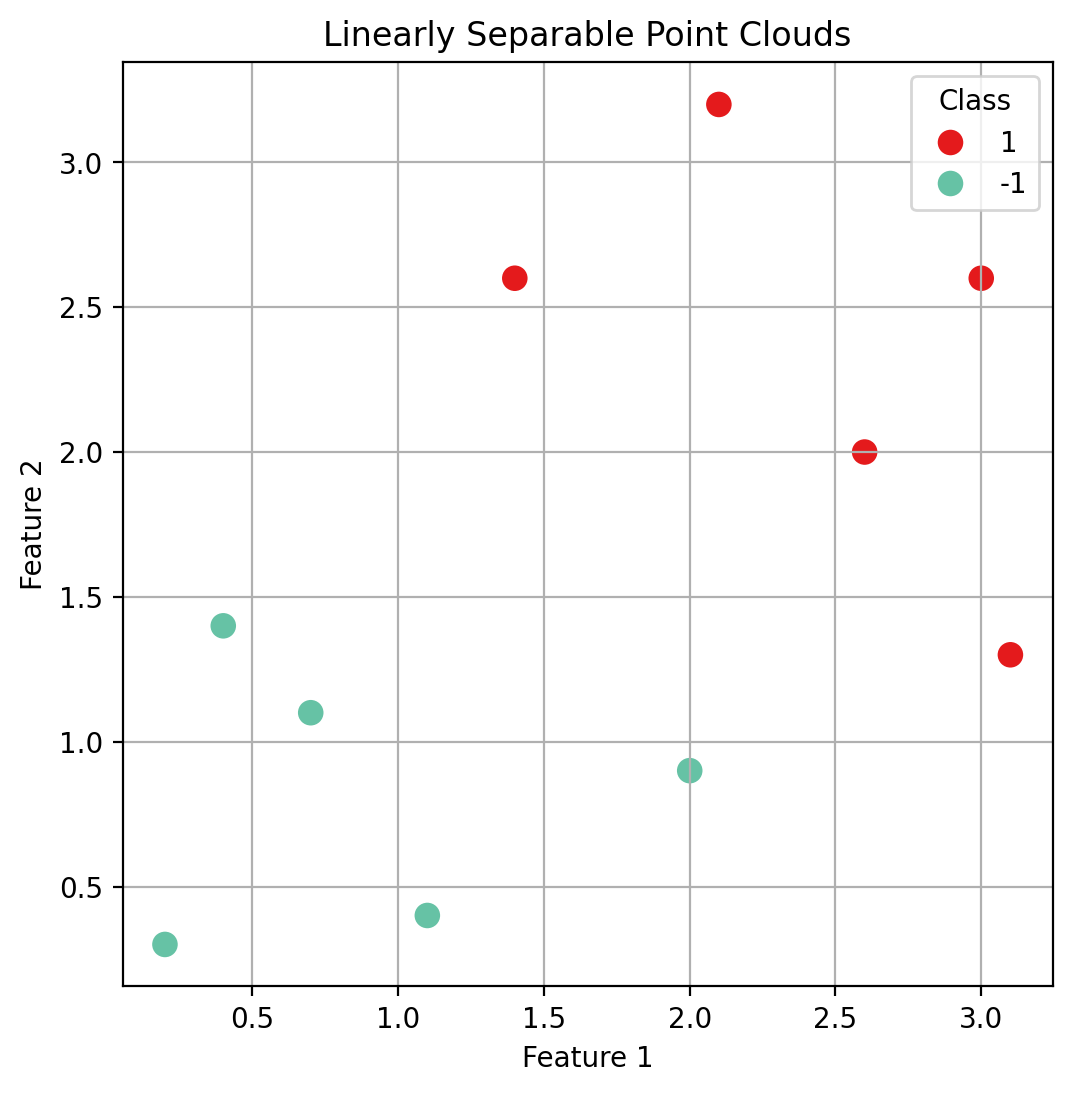

In [5]:
plt.figure(figsize=(6, 6))
# sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1', s=100)
sns.scatterplot(x=X_pos[:, 0], y=X_pos[:, 1], hue=1, palette='Set1', s=100)
sns.scatterplot(x=X_neg[:, 0], y=X_neg[:, 1], hue=-1, palette='Set2', s=100)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linearly Separable Point Clouds')
plt.legend(title='Class')
plt.grid()
plt.show()

In [ ]:
# 1. Check vertical line

print(f"Max x coordinate in negative class: {X_neg[:, 0].max():.4f}")
print(f"Min x coordinate in positive class: {X_pos[:, 0].min():.4f}")

Max x coordinate in negative class: 2.0000
Min x coordinate in positive class: 1.4000


So there is no vertical line that can separate the two classes.

Find a separating line in `Pyomo`. Notice the differences in passing constraints (is pyomo or linprog easier for the problem at hand?)

In [7]:
# Using Pyomo
model2D = pyo.ConcreteModel()
model2D.delta = pyo.Var(domain=pyo.Reals)
model2D.a = pyo.Var(domain=pyo.Reals)
model2D.b = pyo.Var(domain=pyo.Reals)

model2D.obj = pyo.Objective(expr=model2D.delta, sense=pyo.maximize)
model2D.cons = pyo.ConstraintList()

for i in range(len(X_pos)):
    x1, y1 = X_pos[i]
    model2D.cons.add(y1 >= x1 * model2D.a + model2D.b + model2D.delta)
    
for i in range(len(X_neg)):
    x1, y1 = X_neg[i]
    model2D.cons.add(y1 <= x1 * model2D.a + model2D.b - model2D.delta)

# solver = pyo.SolverFactory('glpk')
solver = pyo.SolverFactory("gurobi")
result = solver.solve(model2D, tee=False)

if (result.solver.status == SolverStatus.ok and
    result.solver.termination_condition == TerminationCondition.optimal):
    print("Optimal solution found")
    print(f"a = {pyo.value(model2D.a):.4f}")
    print(f"b = {pyo.value(model2D.b):.4f}")
    print(f"delta = {pyo.value(model2D.delta):.4f}")
else:
    print(result.solver.status, result.solver.termination_condition)

Optimal solution found
a = -0.7647
b = 3.0500
delta = 0.6206


### Do the same with `scipy.optimize.linprog`

In [8]:
n_neg = len(X_neg)
n_pos = len(X_pos)
n = n_neg + n_pos

n_vars = 3  # [a, b, t]

c = np.array([0, 0, -1.0])  # minimize -delta

A_ub = np.ones(shape=(n, 3), dtype=float)
b_ub = np.hstack([X_pos[:, 1], -X_neg[:, 1]], dtype=float)

print(A_ub.shape, b_ub.shape)

for i in range(n_pos):
    A_ub[i, 0] = X_pos[i, 0]

for i in range(n_neg):
    A_ub[n_pos + i, 0] = -X_neg[i, 0]
    A_ub[n_pos + i, 1] = -1.0

res_gap = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=(None, None), method='highs')

print('success:', res_gap.success)
print('status:', res_gap.message)
print(f'a = {res_gap.x[0]:.4f}')
print(f'b = {res_gap.x[1]:.4f}')
print(f'max objective = {-res_gap.fun:.4f}')

(10, 3) (10,)
success: True
status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
a = -0.7647
b = 3.0500
max objective = 0.6206


In [9]:
# Approach A: least squares classifier
# Model score: f(x) = w^T x + b, predicted class is sign(f(x))

A = np.column_stack([X, np.ones(len(X))])
theta_ls, *_ = np.linalg.lstsq(A, y, rcond=None)
w_ls = theta_ls[:2]
b_ls = theta_ls[2]

scores_ls = X @ w_ls + b_ls
pred_ls = np.where(scores_ls >= 0, 1.0, -1.0)
acc_ls = (pred_ls == y).mean()

print('Least-squares w:', w_ls)
print('Least-squares b:', b_ls)
print(f'Least-squares training accuracy: {acc_ls:.2f}')

Least-squares w: [0.48615655 0.60467391]
Least-squares b: -1.7624046495180579
Least-squares training accuracy: 1.00


In [10]:
grid = np.linspace(0, 3.2, 100)
y_grid = model2D.a.value * grid + model2D.b.value
assert abs(w_ls[1]) > 1e-12
y_grid_ls = - (w_ls[0] * grid + b_ls) / w_ls[1]

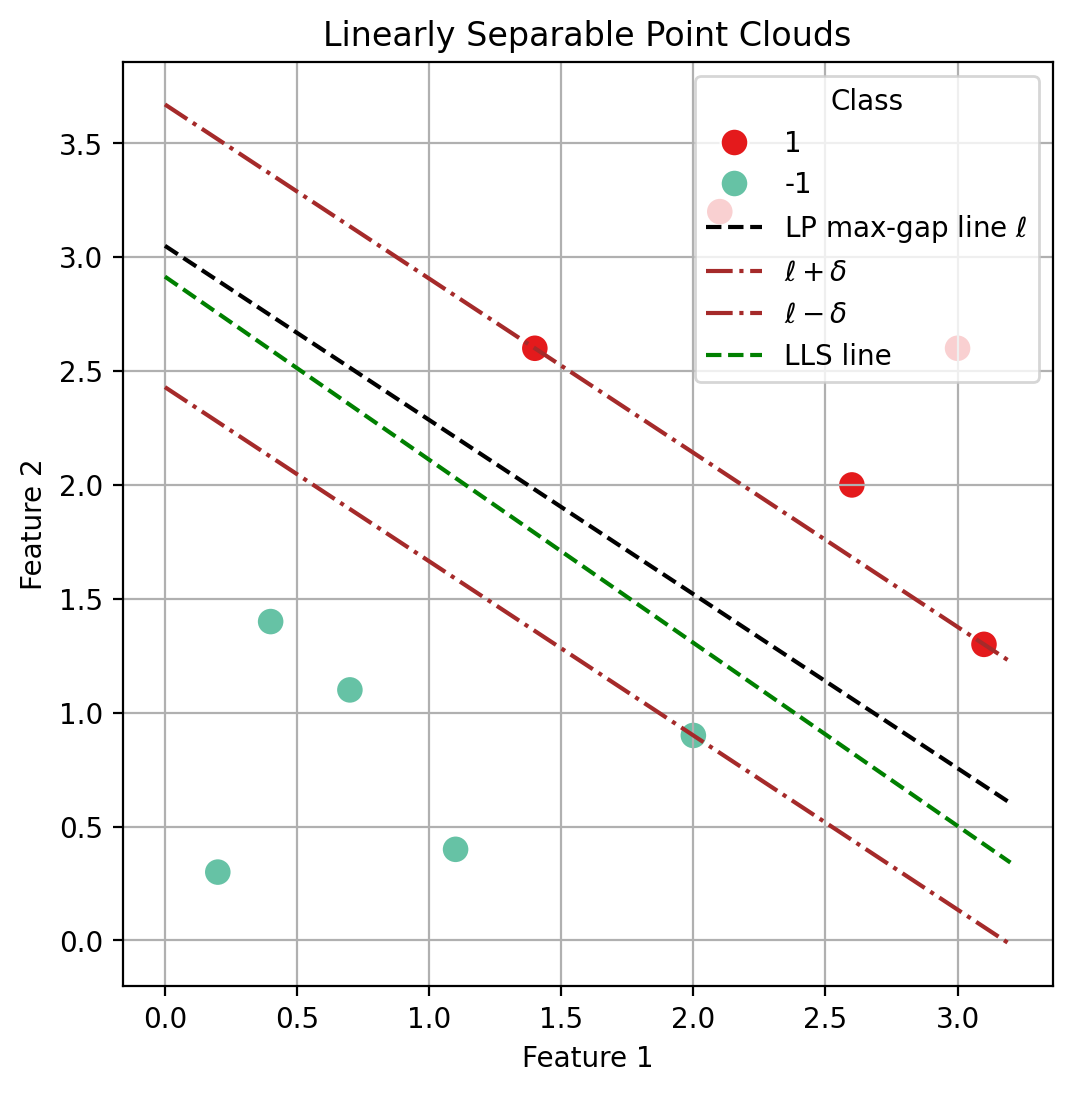

In [11]:
plt.figure(figsize=(6, 6))
# sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1', s=100)
sns.scatterplot(x=X_pos[:, 0], y=X_pos[:, 1], hue=1, palette='Set1', s=100)
sns.scatterplot(x=X_neg[:, 0], y=X_neg[:, 1], hue=-1, palette='Set2', s=100)
sns.lineplot(x=grid, y=y_grid, color='black', linestyle='--', label=r'LP max-gap line $\ell$')
sns.lineplot(x=grid, y=y_grid + model2D.delta.value, color='brown', linestyle='-.', label=r'$\ell + \delta$')
sns.lineplot(x=grid, y=y_grid - model2D.delta.value, color='brown', linestyle='-.', label=r'$\ell - \delta$')
sns.lineplot(x=grid, y=y_grid_ls, color='green', linestyle='--', label='LLS line')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linearly Separable Point Clouds')
plt.legend(title='Class')
plt.grid()
plt.show()

## Fitting a line

In [ ]:
def fit_line_L1_pyomo(x, y, solver_name="glpk", tee=False):
    """
    L1 line fit: minimize sum_i |a*x_i + b - y_i|
    via LP:
        min  sum e_i
        s.t. e_i >= a*x_i + b - y_i
             e_i >= -(a*x_i + b - y_i)
             e_i >= 0

    Returns (a, b, e_values, results).
    """
    assert len(x) == len(y) and len(x) > 0
    n = len(x)

    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, n - 1)

    m.a = pyo.Var(domain=pyo.Reals)
    m.b = pyo.Var(domain=pyo.Reals)
    m.e = pyo.Var(m.I, domain=pyo.NonNegativeReals)

    # objective
    m.obj = pyo.Objective(expr=sum(m.e[i] for i in m.I), sense=pyo.minimize)

    def c_pos_rule(m, i):
        return m.e[i] >= m.a * x[i] + m.b - y[i]

    def c_neg_rule(m, i):
        return m.e[i] >= -(m.a * x[i] + m.b - y[i])

    m.c_pos = pyo.Constraint(m.I, rule=c_pos_rule)
    m.c_neg = pyo.Constraint(m.I, rule=c_neg_rule)

    solver = pyo.SolverFactory(solver_name)
    results = solver.solve(m, tee=tee)

    a_val = pyo.value(m.a)
    b_val = pyo.value(m.b)
    e_vals = [pyo.value(m.e[i]) for i in range(n)]
    return a_val, b_val, e_vals, results

In [21]:
x_fitting = [2, 2, 2, 2, 2] # [0, 1, 2, 3, 4]
y_fitting = [0, 1, 2, 3, 4] #. [0.2, 1.1, 1.9, 3.2, 3.9]

a, b, e, res = fit_line_L1_pyomo(x_fitting, y_fitting, solver_name="glpk")
print("status:", res.solver.status)
print("termination:", res.solver.termination_condition)
print(f"a = {a:.6g}, b = {b:.6g}")
print("sum |residuals| =", sum(e))

status: ok
termination: optimal
a = 1, b = 0
sum |residuals| = 6.0


In [22]:
grid_4 = np.linspace(0, 4, 100)
y_grid_4 = a * grid_4 + b

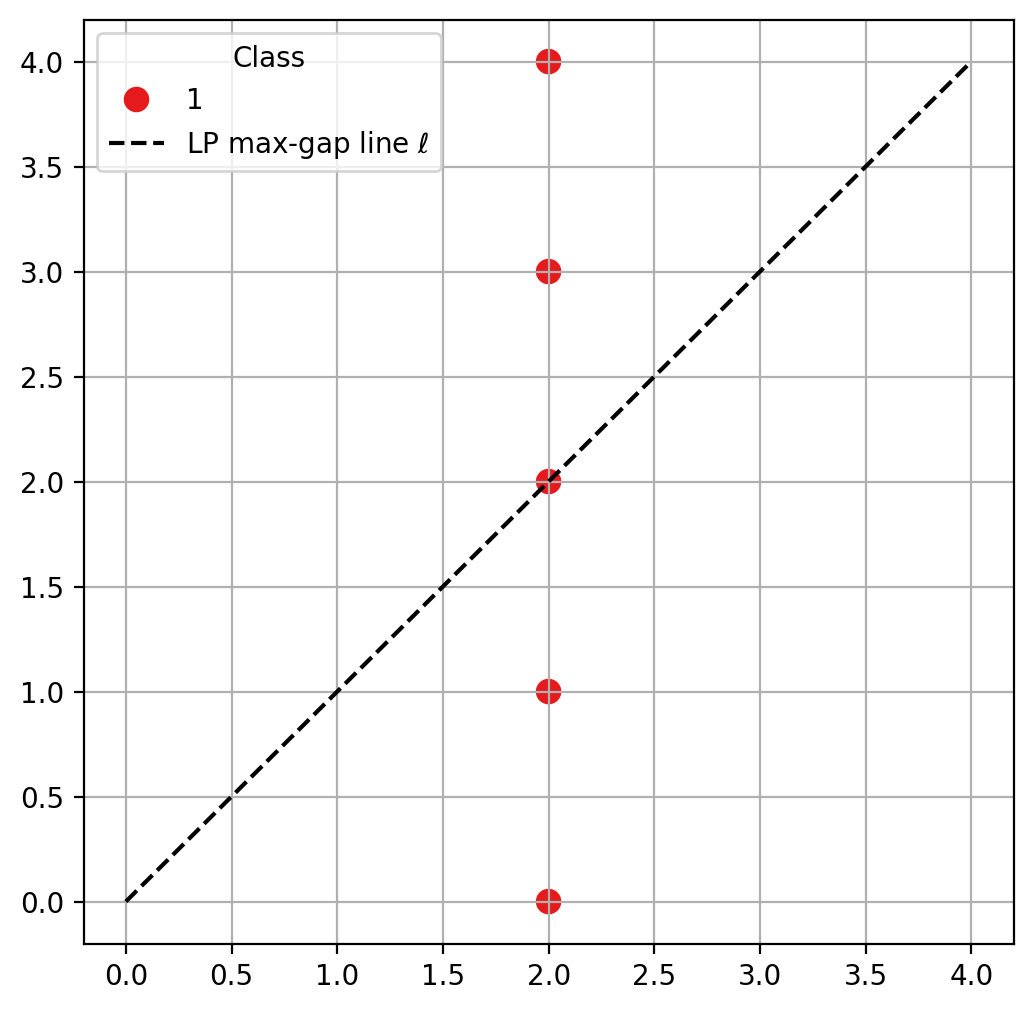

In [23]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=x_fitting, y=y_fitting, hue=1, palette='Set1', s=100)
sns.lineplot(x=grid_4, y=y_grid_4, color='black', linestyle='--', label=r'LP max-gap line $\ell$')

plt.legend(title='Class')
plt.grid()
plt.show()

## 4. Quick comparison

- Use `Pyomo` when you want to write out individual constraints by hand.
- Use `linprog` when you have constraints in matrix form -- or when there is a lot of symmetry it is easy to spot a pattern and write them in matrix form.